In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# função

def U(x, y):
    
    return np.sin(x) * np.cos(y) + 2 * (x * y)**2 / 1000

def grad_U(x, y):

    dU_dx = np.cos(x) * np.cos(y) + 4 * x * y**2 / 1000
    dU_dy = -np.sin(x) * np.sin(y) + 4 * y * x**2 / 1000
    return np.array([dU_dx, dU_dy])

In [19]:
# gradiente descendente
def gradiente_descendente_2D(f, grad_f, r0, alpha=0.1, epsilon=1e-4, max_iter=500):
    traj = [r0]
    losses = [f(r0[0], r0[1])]

    r = np.array(r0, dtype=float)

    for _ in range(max_iter):
        grad = grad_f(r[0], r[1])
        r_new = r - alpha * grad
        traj.append(r_new)
        losses.append(f(r_new[0], r_new[1]))
        if np.linalg.norm(r_new - r) < epsilon:
            break
        r = r_new

    return np.array(traj), losses


In [20]:
# gráfico de contorno
x_vals = np.linspace(-5, 5, 400)
y_vals = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = U(X, Y)

In [21]:
# parâmetros iniciais
r0 = [-1.5, 0.1]
alpha = 0.05
     
traj, losses = gradiente_descendente_2D(U, grad_U, r0, alpha=alpha)

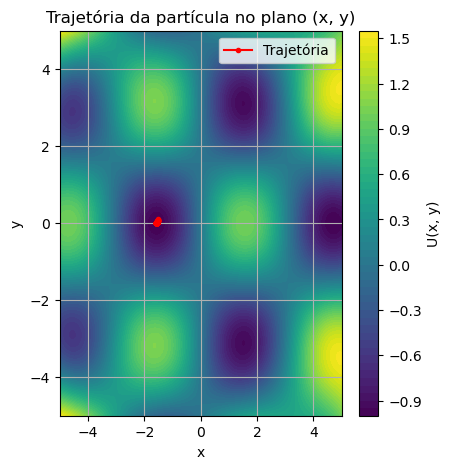

In [22]:
#gráfico a: Contorno com trajetória
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='U(x, y)')
plt.plot(traj[:, 0], traj[:, 1], 'ro-', markersize=3, label='Trajetória')
plt.title('Trajetória da partícula no plano (x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

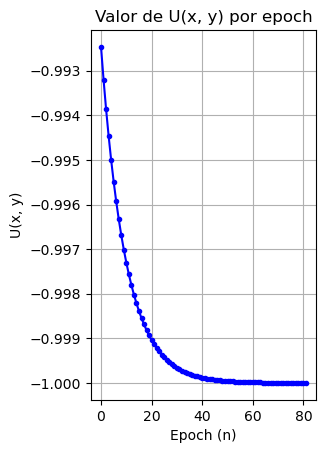

In [23]:
#Gráfico b: Contorno com trajetória
plt.subplot(1, 2, 2)
plt.plot(losses, 'b-o', markersize=3)
plt.title('Valor de U(x, y) por epoch')
plt.xlabel('Epoch (n)')
plt.ylabel('U(x, y)')
plt.grid(True)

In [24]:
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>